# Task 5 - Customer Retention Strategies
**Datasets:** segmented_churn_data.csv, customers_with_ltv_scores.csv, high_value_at_risk_customers.csv  
Using all findings from Tasks 2, 3 and 4 to propose real, data-backed strategies to reduce churn
In this task, insights from exploratory analysis, segmentation, and predictive modelling were used to propose customer retention strategies.

The objective is to identify potential actions based on observed churn patterns and customer value analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('segmented_churn_data.csv')
df_ltv = pd.read_csv('customers_with_ltv_scores.csv')
at_risk = pd.read_csv('high_value_at_risk_customers.csv')

print("Main dataset:", df.shape)
print("LTV dataset:", df_ltv.shape)
print("High-value at-risk customers:", len(at_risk))

Main dataset: (7043, 25)
LTV dataset: (7043, 24)
High-value at-risk customers: 867


## Section 1: Summary of Key Churn Drivers
This section summarizes the key churn drivers identified from exploratory analysis and segmentation.

These factors form the basis for the retention strategies proposed in subsequent sections.

In [ ]:
print("=" * 55)
print("KEY CHURN DRIVERS IDENTIFIED FROM ANALYSIS")
print("=" * 55)
print()
print("1. CONTRACT TYPE:")
for c, r in df.groupby('Contract')['Churn'].mean().mul(100).sort_values(ascending=False).items():
    print(f"   {c}: {r:.1f}% churn rate")
print()
print("2. CUSTOMER TENURE:")
for seg in ['New (0-12m)', 'Mid-term (13-36m)', 'Long-term (37+m)']:
    subset = df[df['Tenure_Segment'] == seg]
    if len(subset) > 0:
        print(f"   {seg}: {subset['Churn'].mean()*100:.1f}% churn rate ({len(subset):,} customers)")
print()
print("3. PAYMENT METHOD:")
for c, r in df.groupby('PaymentMethod')['Churn'].mean().mul(100).sort_values(ascending=False).items():
    print(f"   {c}: {r:.1f}%")
print()
print("4. INTERNET SERVICE:")
for c, r in df.groupby('InternetService')['Churn'].mean().mul(100).sort_values(ascending=False).items():
    print(f"   {c}: {r:.1f}%")

KEY CHURN DRIVERS IDENTIFIED FROM ANALYSIS

1. CONTRACT TYPE:
   Month-to-month: 42.7% churn rate
   One year: 11.3% churn rate
   Two year: 2.8% churn rate

2. CUSTOMER TENURE:
   New (0-12m): 47.4% churn rate (2,186 customers)
   Mid-term (13-36m): 25.5% churn rate (1,856 customers)
   Long-term (37+m): 11.9% churn rate (3,001 customers)

3. PAYMENT METHOD:
   Electronic check: 45.3%
   Mailed check: 19.1%
   Bank transfer (automatic): 16.7%
   Credit card (automatic): 15.2%

4. INTERNET SERVICE:
   Fiber optic: 41.9%
   DSL: 19.0%
   No: 7.4%


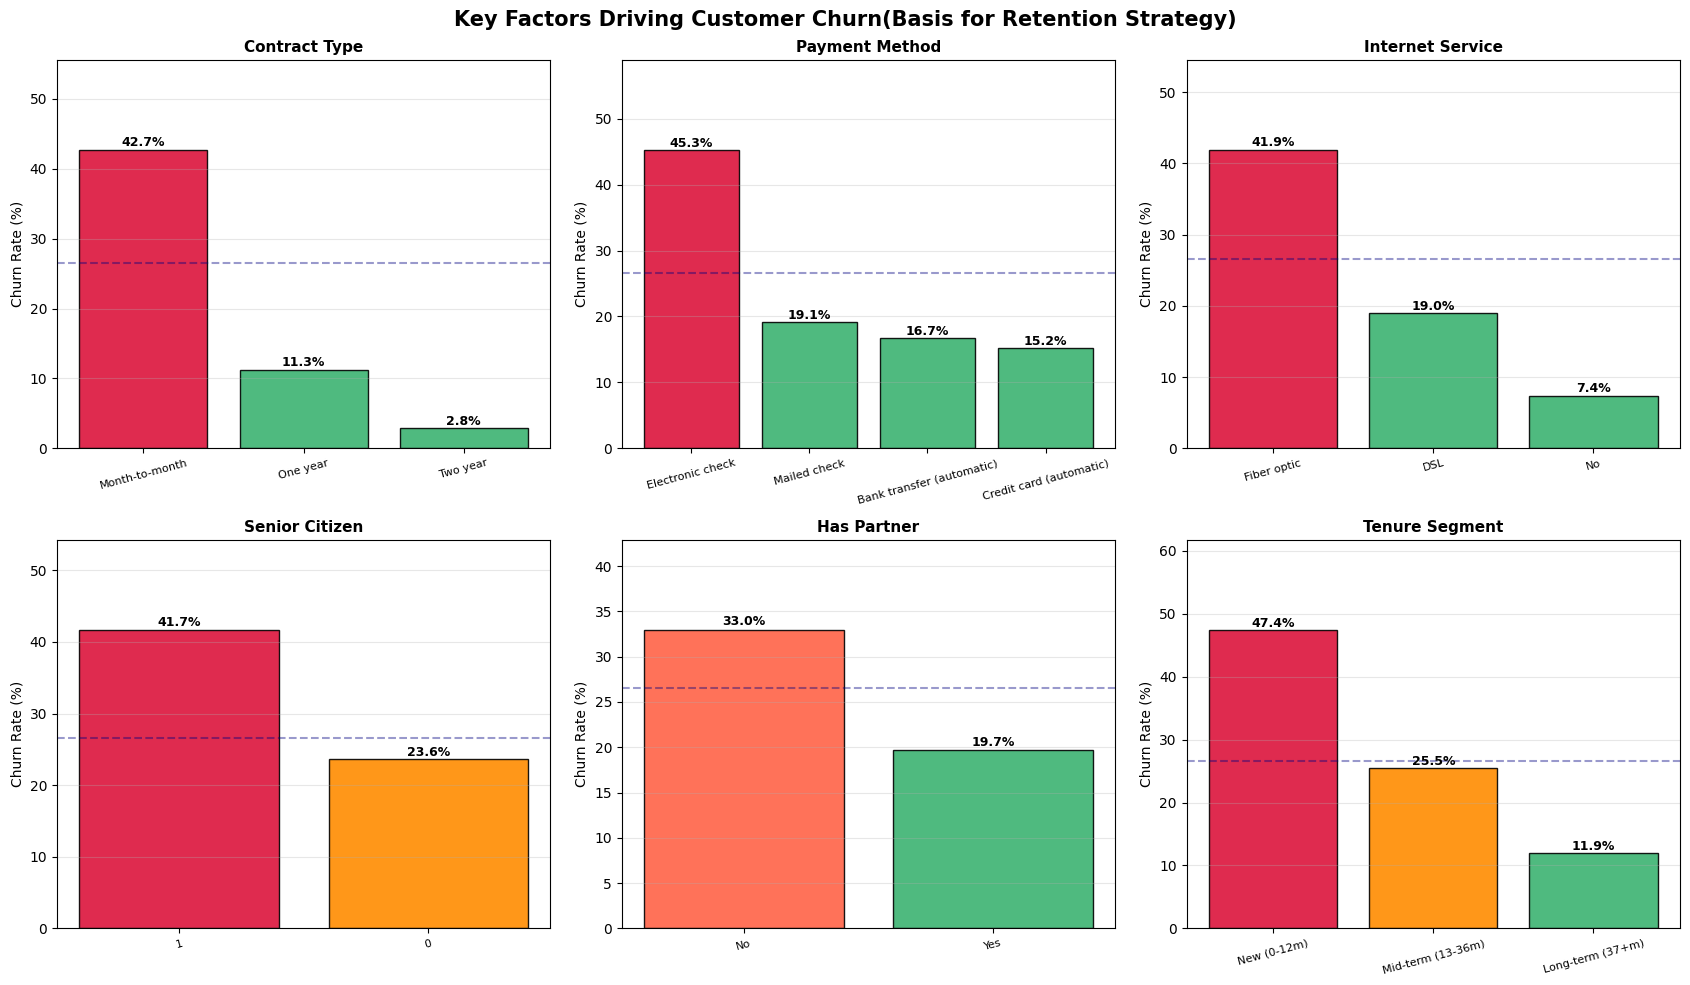

In [ ]:
# visualising the 6 key drivers side by side
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Key Factors Driving Customer Churn(Basis for Retention Strategy)', fontsize=15, fontweight='bold')

factors = [
    ('Contract', 'Contract Type'),
    ('PaymentMethod', 'Payment Method'),
    ('InternetService', 'Internet Service'),
    ('SeniorCitizen', 'Senior Citizen'),
    ('Partner', 'Has Partner'),
    ('Tenure_Segment', 'Tenure Segment')
]

for ax, (col, title) in zip(axes.flatten(), factors):
    churn_rate = df.groupby(col, observed=True)['Churn'].mean().mul(100).sort_values(ascending=False)
    colors = ['crimson' if v > 40 else 'tomato' if v > 30 else 'darkorange' if v > 20 else 'mediumseagreen'
              for v in churn_rate.values]
    bars = ax.bar(range(len(churn_rate)), churn_rate.values, color=colors, edgecolor='black', alpha=0.9)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=15, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Churn Rate (%)')
    ax.axhline(df['Churn'].mean()*100, color='navy', linestyle='--', alpha=0.4, linewidth=1.5)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, churn_rate.max() * 1.3)

plt.tight_layout()
plt.savefig('strategy_01_churn_drivers.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 2: Customer Lifetime Value Summary
This section summarizes the distribution of Customer Lifetime Value (LTV) across customers.

The objective is to compare estimated customer value levels before outlining retention approaches.

In [ ]:
print("=== Customer Lifetime Value Summary ===")
print()
print("LTV by Contract Type:")
print(df_ltv.groupby('Contract')['LTV'].agg(['mean','median','count']).round(1).to_string())
print()
print("Overall LTV stats:")
print(f"  Average LTV: ${df_ltv['LTV'].mean():,.0f}")
print(f"  Median LTV:  ${df_ltv['LTV'].median():,.0f}")
print(f"  Top 10% LTV threshold: ${df_ltv['LTV'].quantile(0.9):,.0f}+")
print()
print("High-value at-risk customers:")
print(f"  Count: {len(at_risk):,}")
print(f"  Monthly revenue at stake: ${at_risk['MonthlyCharges'].sum():,.0f}")
print(f"  Avg LTV of this group: ${at_risk['LTV'].mean():,.0f}")

=== Customer Lifetime Value Summary ===

LTV by Contract Type:
                  mean  median  count
Contract                             
Month-to-month  1665.7  1536.3   3875
One year        1417.6  1164.6   1473
Two year         652.8   347.2   1695

Overall LTV stats:
  Average LTV: $1,370
  Median LTV:  $1,211
  Top 10% LTV threshold: $2,730+

High-value at-risk customers:
  Count: 867
  Monthly revenue at stake: $71,284
  Avg LTV of this group: $1,759


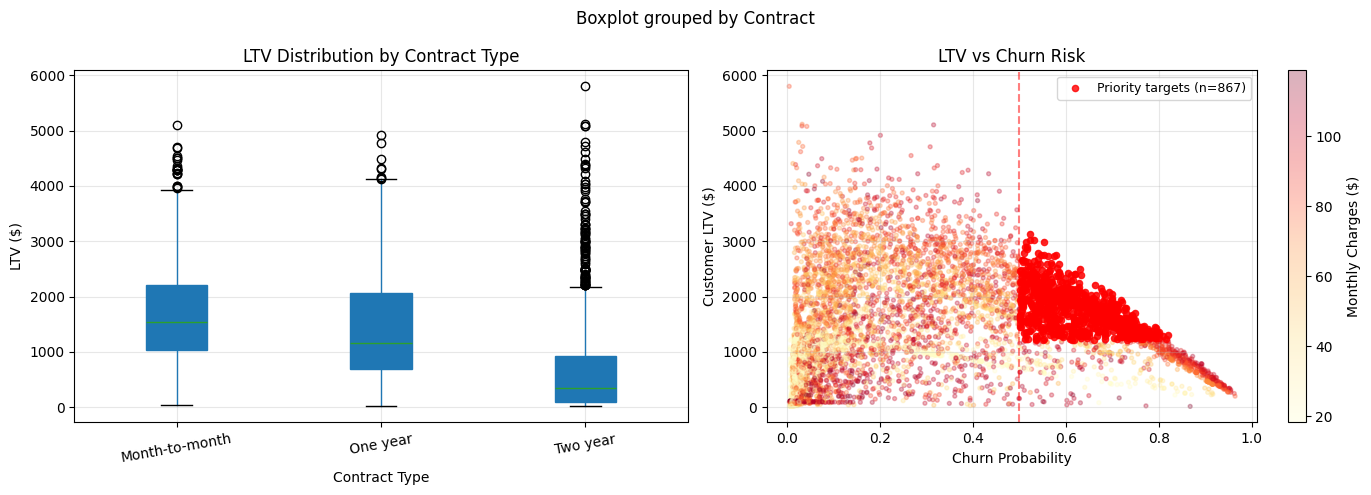

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold')

# LTV distribution by contract
df_ltv.boxplot(column='LTV', by='Contract', ax=axes[0], 
               patch_artist=True)
axes[0].set_title('LTV Distribution by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('LTV ($)')
axes[0].grid(alpha=0.3)
plt.sca(axes[0])
plt.xticks(rotation=10)

# LTV vs churn probability scatter
sc = axes[1].scatter(df_ltv['Churn_Probability'], df_ltv['LTV'],
                     c=df_ltv['MonthlyCharges'], cmap='YlOrRd', alpha=0.3, s=8)
plt.colorbar(sc, ax=axes[1], label='Monthly Charges ($)')
axes[1].scatter(at_risk['Churn_Probability'], at_risk['LTV'],
                color='red', s=20, alpha=0.8,
                label=f'Priority targets (n={len(at_risk)})', zorder=5)
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Customer LTV ($)')
axes[1].set_title('LTV vs Churn Risk')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_02_ltv.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 3: Proposed Retention Strategies
Based on the observed churn patterns and customer segmentation results, the following retention approaches are proposed.
Each strategy is aligned with specific customer segments identified during analysis.

In [ ]:
# calculating the revenue impact for each strategy
total_monthly = df['MonthlyCharges'].sum()

print("=== Revenue Impact Calculations ===")
print(f"Total monthly revenue: ${total_monthly:,.0f}")
print()

# Strategy 1: contract upgrade
m2m = df[df['Contract'] == 'Month-to-month']
m2m_churners = m2m[m2m['Churn'] == 1]
print(f"Strategy 1 - Contract Upgrade:")
print(f"  Month-to-month customers: {len(m2m):,}")
print(f"  Current churners: {len(m2m_churners):,}/month")
m2m_revenue_at_risk = m2m_churners['MonthlyCharges'].sum()
print(f"  Monthly revenue at risk: ${m2m_revenue_at_risk:,.0f}")
print(f"  If 20% of churners retained: +${m2m_revenue_at_risk*0.2:,.0f}/month")
print()

# Strategy 2: new customer onboarding
new_customers = df[df['tenure'] <= 12]
new_churners = new_customers[new_customers['Churn'] == 1]
print(f"Strategy 2 - New Customer Onboarding:")
print(f"  Customers with tenure ≤12 months: {len(new_customers):,}")
print(f"  New customer churners: {len(new_churners):,}")
print(f"  Revenue at risk: ${new_churners['MonthlyCharges'].sum():,.0f}/month")
print()

# Strategy 3: payment method migration
echeck = df[df['PaymentMethod'] == 'Electronic check']
echeck_churners = echeck[echeck['Churn'] == 1]
print(f"Strategy 3 - Payment Method Migration:")
print(f"  Electronic check customers: {len(echeck):,}")
print(f"  Churners in this group: {len(echeck_churners):,}")
print(f"  Revenue at risk: ${echeck_churners['MonthlyCharges'].sum():,.0f}/month")
print()

# Strategy 4: high-value proactive
print(f"Strategy 4 - High-Value Proactive Outreach:")
print(f"  Priority customers: {len(at_risk):,}")
print(f"  Monthly revenue at stake: ${at_risk['MonthlyCharges'].sum():,.0f}")

=== Revenue Impact Calculations ===
Total monthly revenue: $456,117

Strategy 1 - Contract Upgrade:
  Month-to-month customers: 3,875
  Current churners: 1,655/month
  Monthly revenue at risk: $120,847
  If 20% of churners retained: +$24,169/month

Strategy 2 - New Customer Onboarding:
  Customers with tenure ≤12 months: 2,186
  New customer churners: 1,037
  Revenue at risk: $68,954/month

Strategy 3 - Payment Method Migration:
  Electronic check customers: 2,365
  Churners in this group: 1,071
  Revenue at risk: $84,289/month

Strategy 4 - High-Value Proactive Outreach:
  Priority customers: 867
  Monthly revenue at stake: $71,284


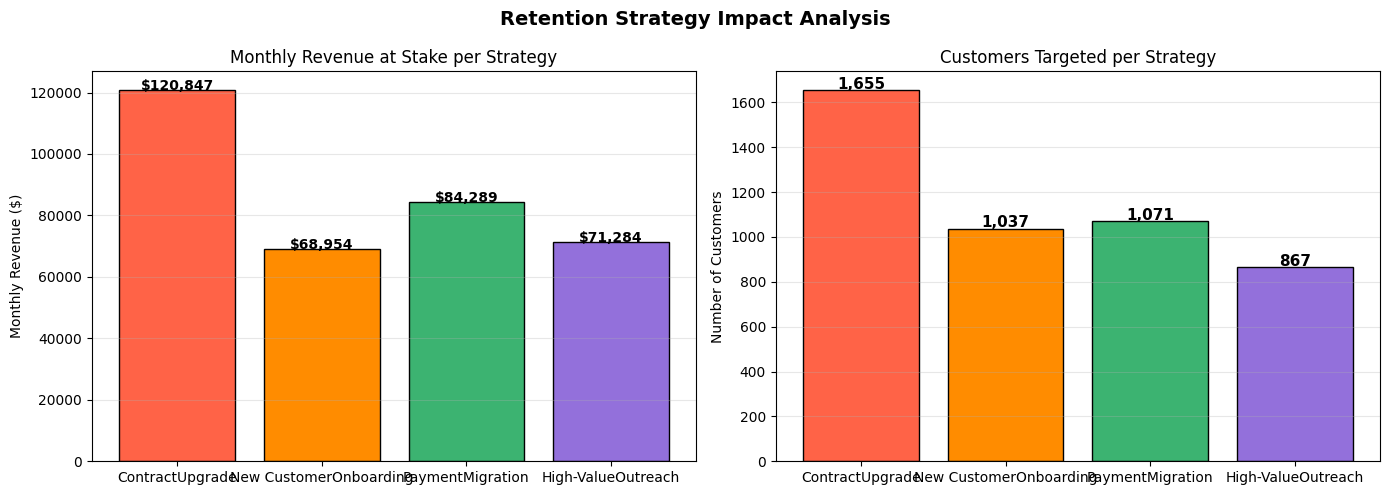

In [ ]:
# strategy comparison chart
strategies = ['ContractUpgrade', 'New CustomerOnboarding', 'PaymentMigration', 'High-ValueOutreach']
revenue_at_risk = [
    df[df['Contract']=='Month-to-month'][df['Churn']==1]['MonthlyCharges'].sum(),
    df[df['tenure']<=12][df['Churn']==1]['MonthlyCharges'].sum(),
    df[df['PaymentMethod']=='Electronic check'][df['Churn']==1]['MonthlyCharges'].sum(),
    at_risk['MonthlyCharges'].sum()
]
implementation_cost = ['Medium', 'Low', 'Very Low', 'High']
colors_strat = ['tomato', 'darkorange', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Retention Strategy Impact Analysis', fontsize=14, fontweight='bold')

bars = axes[0].bar(strategies, revenue_at_risk, color=colors_strat, edgecolor='black')
for bar, val in zip(bars, revenue_at_risk):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Monthly Revenue at Stake per Strategy')
axes[0].set_ylabel('Monthly Revenue ($)')
axes[0].grid(axis='y', alpha=0.3)

# customer count per strategy
customer_counts = [
    len(df[df['Contract']=='Month-to-month'][df['Churn']==1]),
    len(df[df['tenure']<=12][df['Churn']==1]),
    len(df[df['PaymentMethod']=='Electronic check'][df['Churn']==1]),
    len(at_risk)
]
axes[1].bar(strategies, customer_counts, color=colors_strat, edgecolor='black')
for bar, val in zip(axes[1].patches, customer_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Customers Targeted per Strategy')
axes[1].set_ylabel('Number of Customers')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_03_impact.png', bbox_inches='tight', dpi=120)
plt.show()

=== Strategy Priority Table ===
               Strategy  Target_Customers Revenue_At_Risk Implementation_Cost Expected_Impact  Priority
New Customer Onboarding              2186         $68,954                 Low       Very High         1
       Contract Upgrade              3875        $120,847              Medium            High         2
    High-Value Outreach               867         $71,284                High            High         2
      Payment Migration              2365         $84,289            Very Low            High         3


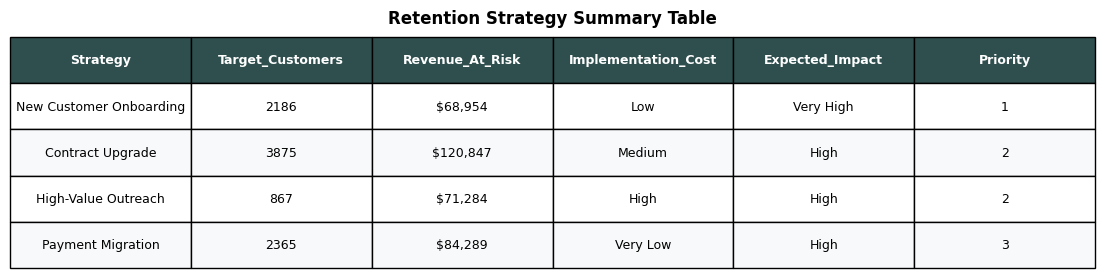


Task 5 complete!
# the revenue impact numbers were the most interesting part of this task for me


In [ ]:
# priority action table
strategy_summary = pd.DataFrame({
    'Strategy': ['Contract Upgrade', 'New Customer Onboarding', 'Payment Migration', 'High-Value Outreach'],
    'Target_Customers': [len(m2m), len(new_customers), len(echeck), len(at_risk)],
    'Revenue_At_Risk': [f"${revenue_at_risk[0]:,.0f}", f"${revenue_at_risk[1]:,.0f}",
                        f"${revenue_at_risk[2]:,.0f}", f"${at_risk['MonthlyCharges'].sum():,.0f}"],
    'Implementation_Cost': ['Medium', 'Low', 'Very Low', 'High'],
    'Expected_Impact': ['High', 'Very High', 'High', 'High'],
    'Priority': [2, 1, 3, 2]
}).sort_values('Priority')

print("=== Strategy Priority Table ===")
print(strategy_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
table = ax.table(
    cellText=strategy_summary.values,
    colLabels=strategy_summary.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('darkslategray')
        cell.set_text_props(color='white', fontweight='bold')
    elif key[0] % 2 == 0:
        cell.set_facecolor('#f8f9fa')
plt.title('Retention Strategy Summary Table', fontsize=12, fontweight='bold', pad=10)
plt.savefig('strategy_04_summary_table.png', bbox_inches='tight', dpi=120)
plt.show()
print()
print("Task 5 complete!")
print("# the revenue impact numbers were the most interesting part of this task for me")